# Tracing chess position information in Qwen3.5
## Verified results and artifact inspection notebook

**Model:** Qwen3.5-4B-Base  
**Assay:** causal transplantation of recurrent and attention KV cache contents between matched chess histories  
**Evaluation:** 100 held-out pairs, 32 continuation pairs, and 30 transposition triplets

The model evaluation was run on a Kaggle T4. This Colab presents the preserved outputs and can verify and reanalyse the compact artifact bundle without downloading or rerunning the 4B model. Only linear ridge readouts were trained; Qwen's weights remained frozen.

## Research question

When Qwen3.5 infers a chess position from a sequence of UCI moves, how do its recurrent memory and full-attention KV cache differ in the information they carry across a context boundary? I tested both behavioral influence and linear board-state accessibility, because a decodable representation is not automatically one the model uses.

## Main conclusion

Replacing KV content produced a much larger donor-specific shift in legal-move preference than replacing recurrent content. However, zeroing recurrent content still destroyed competent behavior. Crossed-cache readouts mixed both donors rather than reconstructing one complete donor board. The result is therefore a channel asymmetry in this assay, not evidence that KV alone stores the model's world.

## Inspect or reanalyse the artifact bundle

Upload `qwen35_chess_memory_review_bundle.tar.gz` when prompted. The bundle contains the experiment script, frozen configuration, manifest, raw result journals, summary, verification report, and original figures. It excludes model weights, caches, probe arrays, and extracted features.

In [ ]:
from pathlib import Path
import tarfile

try:
    from google.colab import files
except ImportError as exc:
    raise RuntimeError('Run this upload cell in Google Colab.') from exc

uploaded = files.upload()
archive_names = [name for name in uploaded if name.endswith(('.tar.gz', '.tgz'))]
assert len(archive_names) == 1, 'Upload exactly one .tar.gz review bundle.'
archive = Path(archive_names[0])
extract_root = Path('/content/qwen35_chess_review')
extract_root.mkdir(parents=True, exist_ok=True)
with tarfile.open(archive, 'r:gz') as tar:
    root = extract_root.resolve()
    for member in tar.getmembers():
        target = (extract_root / member.name).resolve()
        assert target == root or root in target.parents, f'Unsafe archive path: {member.name}'
    tar.extractall(extract_root)
RUN_DIR = extract_root / 'run'
assert (RUN_DIR / 'summary.json').is_file()
print('Ready:', RUN_DIR)

In [ ]:
# These values are also recomputed from raw token log-probabilities below.
print(SAVED_RESULT_SUMMARY if 'SAVED_RESULT_SUMMARY' in globals() else '''VERIFIED SAVED RESULTS
Model: Qwen/Qwen3.5-4B-Base
Primary held-out pairs: 100
Recurrent donor effect: 0.354 nats [0.195, 0.519]
KV donor effect: 3.511 nats [2.960, 4.077]
KV minus recurrent: 3.157 nats [2.603, 3.711]
Intact balanced candidate accuracy: 78.5% [73.5%, 83.0%]
Recurrent-zeroed accuracy: 49.5% [47.5%, 51.5%]
KV-zeroed accuracy: 55.5% [51.0%, 60.0%]
Intact changed-square readout: 61.0% [59.1%, 62.8%]
Orderless changed-square baseline: 53.0%
Exact 64-square recovery: 0.5%''')

VERIFIED SAVED RESULTS
Model: Qwen/Qwen3.5-4B-Base
Primary held-out pairs: 100
Recurrent donor effect: 0.354 nats [0.195, 0.519]
KV donor effect: 3.511 nats [2.960, 4.077]
KV minus recurrent: 3.157 nats [2.603, 3.711]
Intact balanced candidate accuracy: 78.5% [73.5%, 83.0%]
Recurrent-zeroed accuracy: 49.5% [47.5%, 51.5%]
KV-zeroed accuracy: 55.5% [51.0%, 60.0%]
Intact changed-square readout: 61.0% [59.1%, 62.8%]
Orderless changed-square baseline: 53.0%
Exact 64-square recovery: 0.5%


## Figure 1  Memory-channel controls

Both erasures damaged behavior and the linear readout. Dashed lines show the fixed-preference behavioral baseline and the strongest cheap readout baseline. Zeroing preserves cache shapes and positions; it does not remove the corresponding layers.

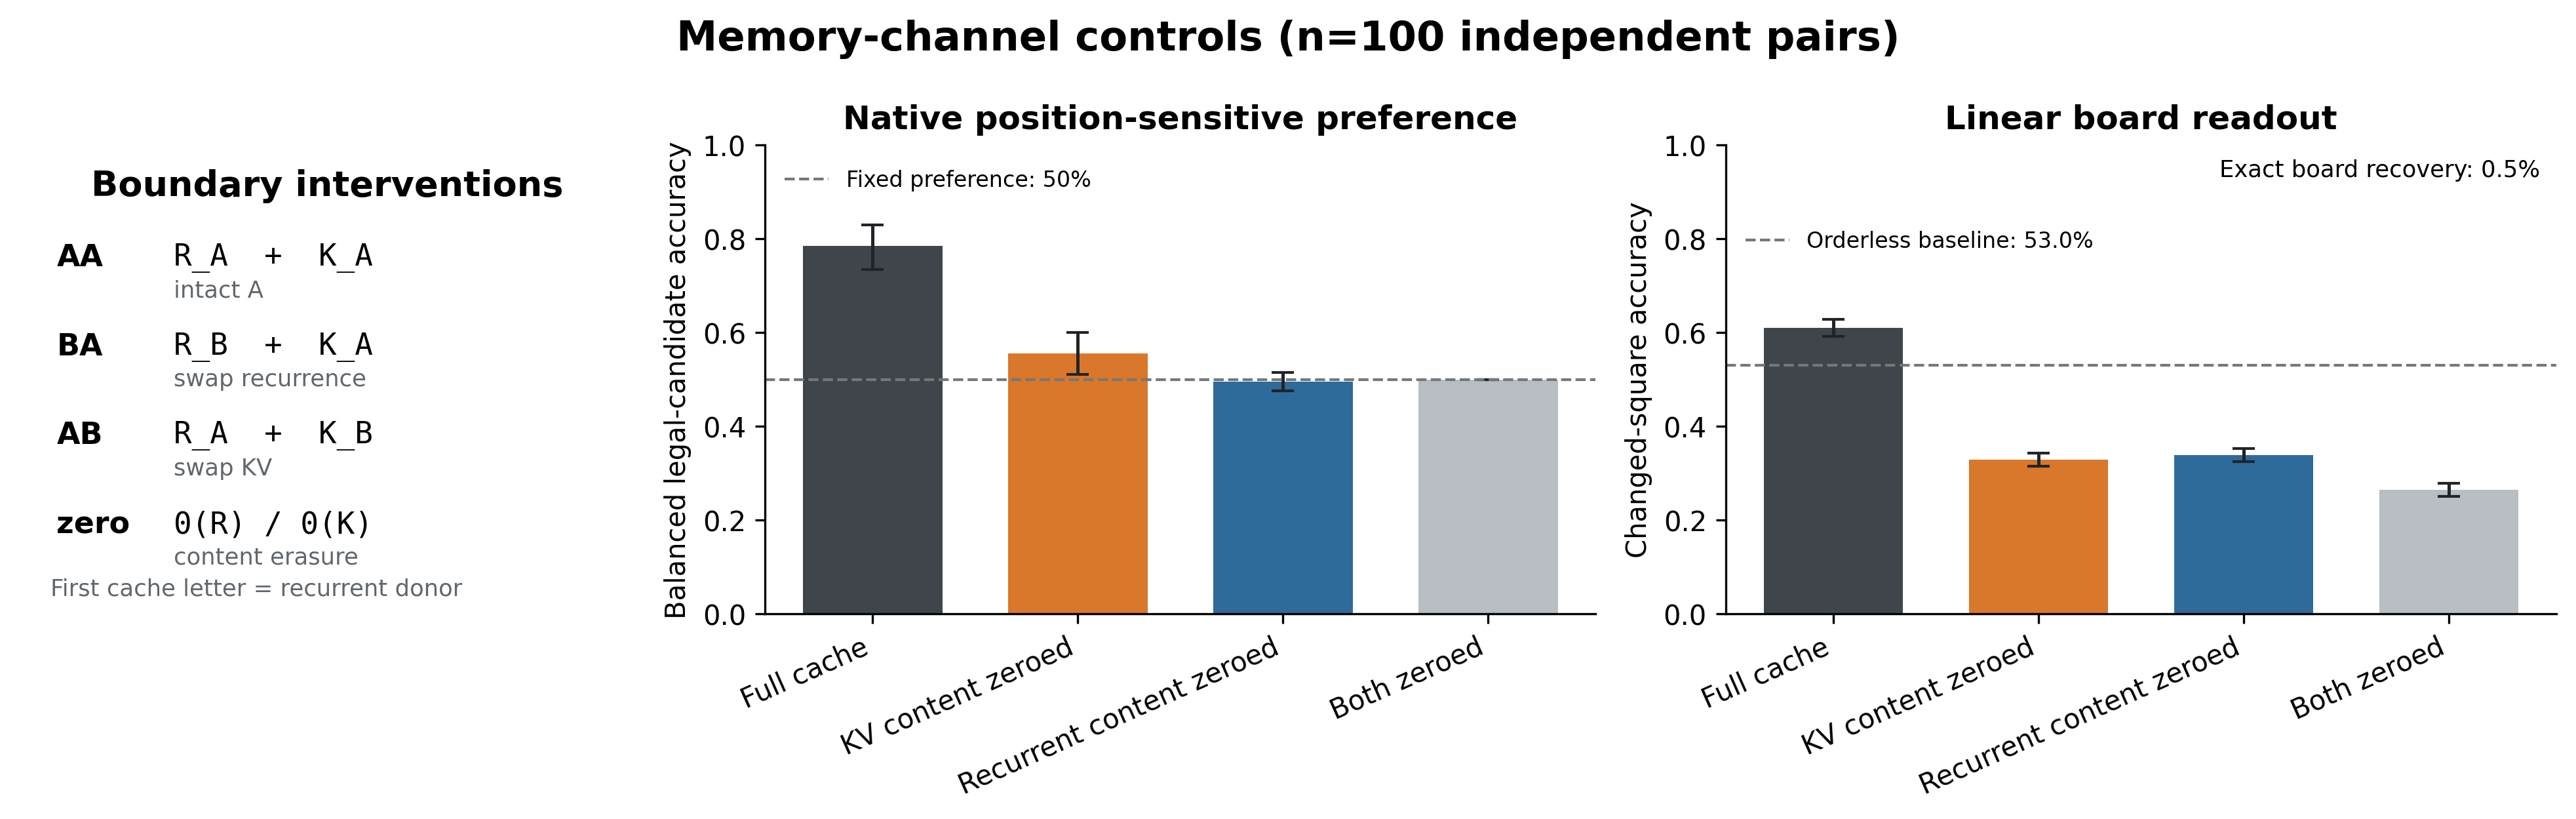

In [ ]:
from IPython.display import display
from PIL import Image
display(Image.open(RUN_DIR / 'figures/01_memory_conditions.png'))

## Figure 2  Donor influence

KV donor changes caused the larger behavioral shift, while the crossed-cache readout remained mixed. The same-position behavioral result was 50% before and after swapping, so it cannot demonstrate preserved competent behavior.

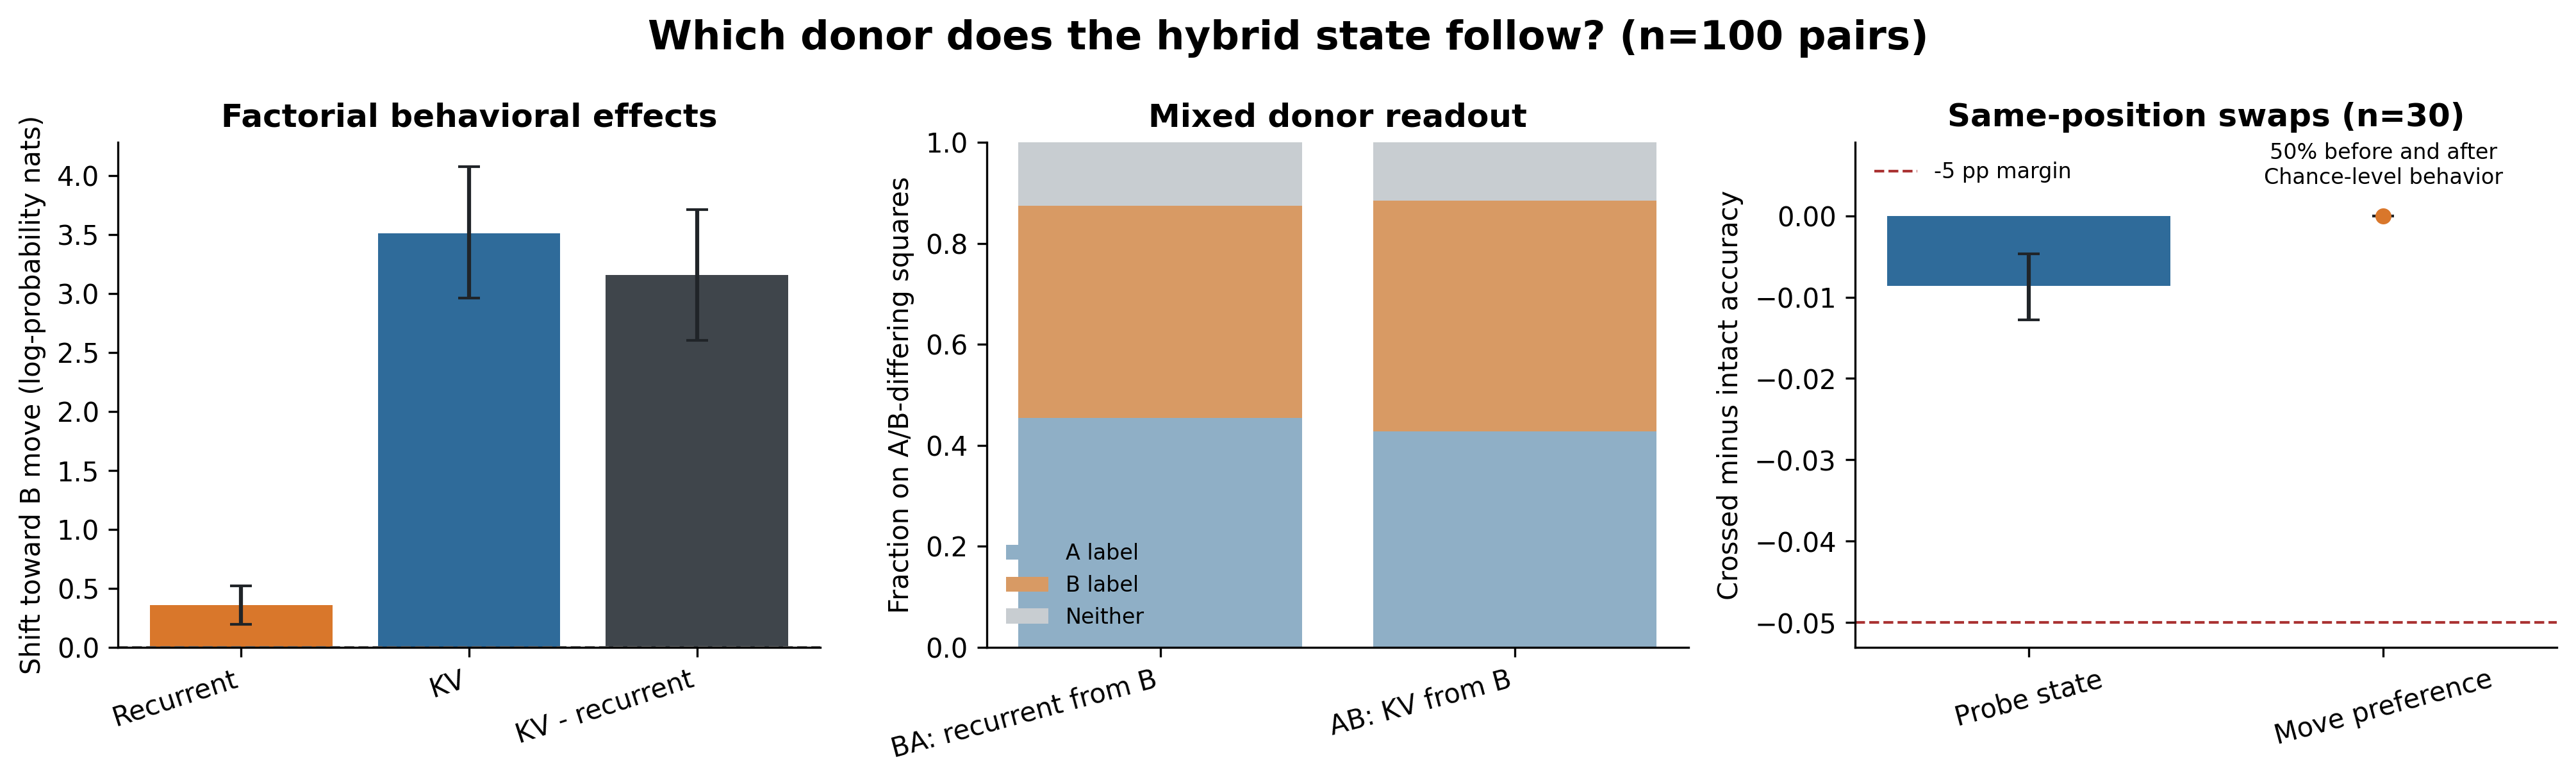

In [ ]:
display(Image.open(RUN_DIR / 'figures/02_donor_following.png'))

## Figure 3  Continued processing

KV donor influence remained positive after one, two, and four additional plies. Both recurrent and attention layers processed those new tokens, so this does not localize the updating computation. Shading shows the saved paired cluster-bootstrap intervals.

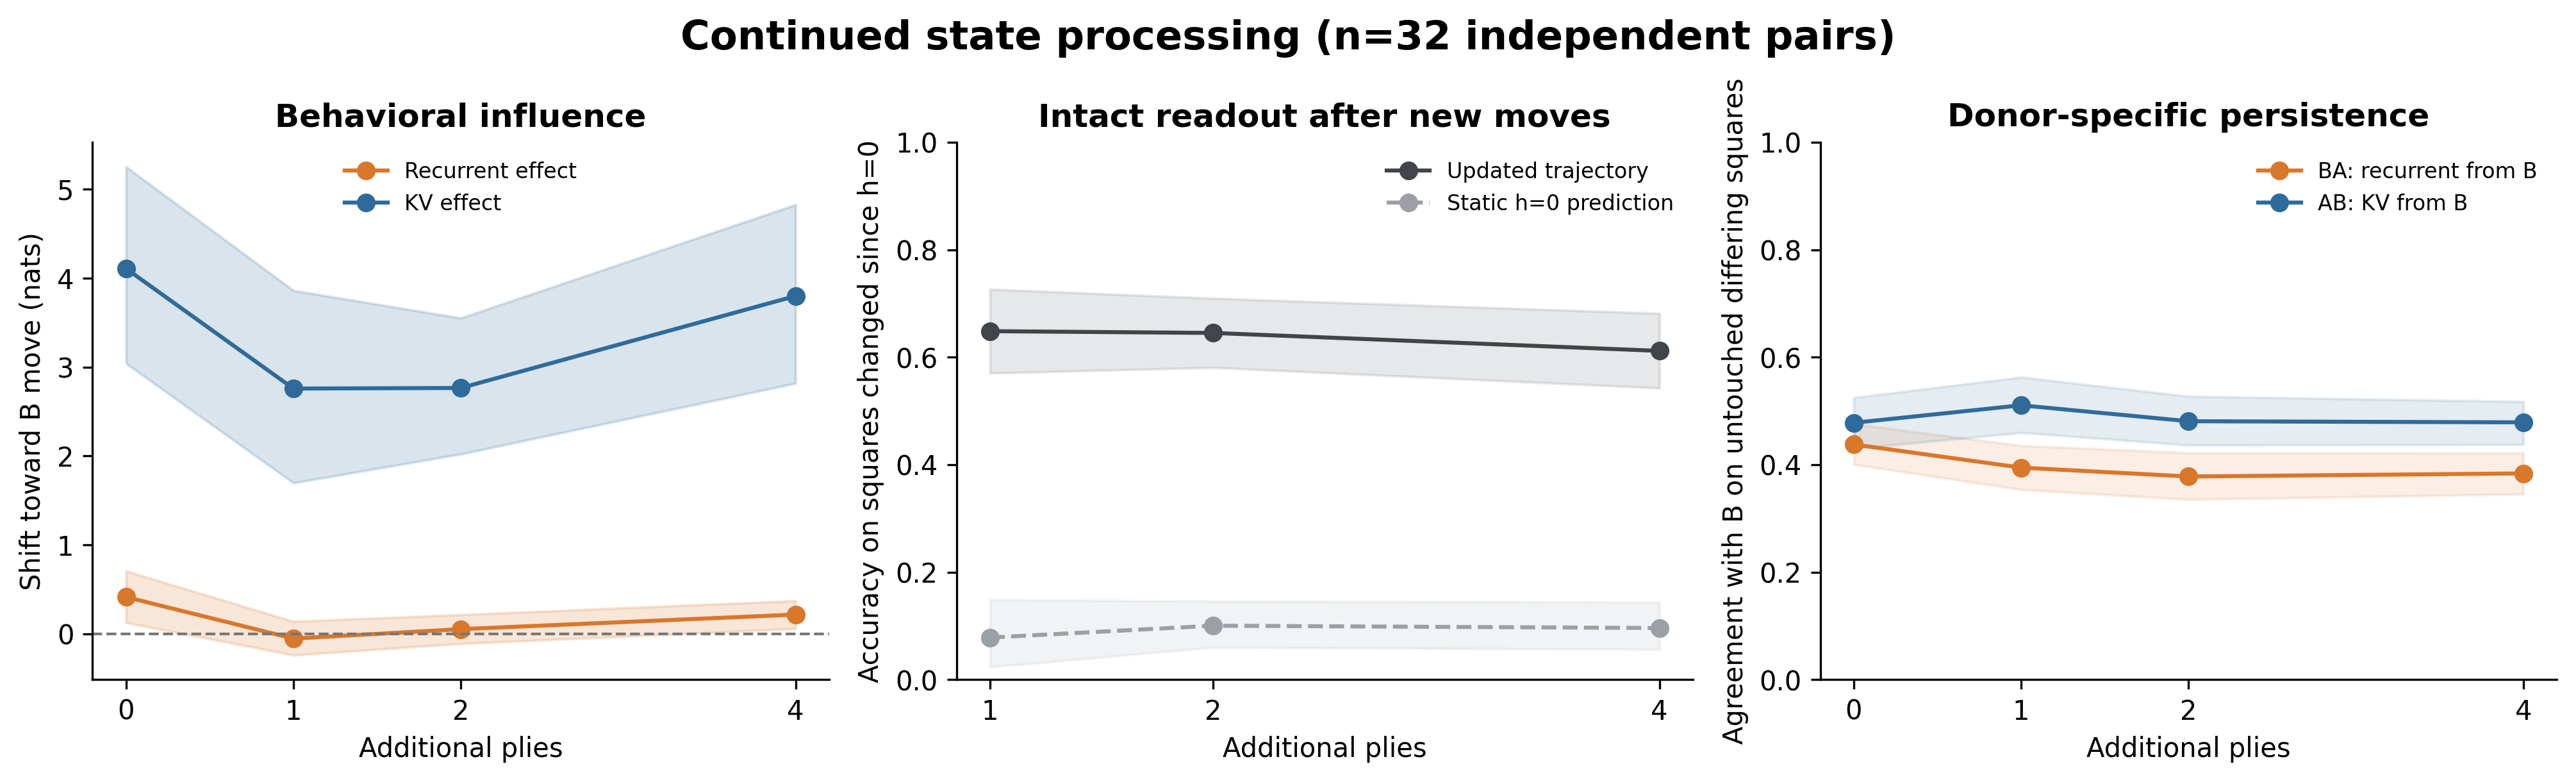

In [ ]:
display(Image.open(RUN_DIR / 'figures/03_continuation.png'))

## Study design

- Real January 2013 Lichess game histories were rendered as plain UCI move sequences. Board states and legality labels came from `python-chess` and were never provided to the model.
- Matched positions had equal ply count, tokenized history length, side to move, piece count, and check status.
- Each pair had move *a*, legal only in A, and move *b*, legal only in B. Candidate selection did not use model scores.
- `AA=(R_A,K_A)`, `BB=(R_B,K_B)`, `BA=(R_B,K_A)`, and `AB=(R_A,K_B)`.
- Candidate behavior used full-continuation log-probabilities. Linear ridge readouts predicted 64 square occupancies plus side to move, castling rights, and en-passant state.
- Intervals used 10,000 paired cluster-bootstrap samples. They measure variation across selected examples, not across models or independent experimental replications.

## Verify included artifacts

In [ ]:
import hashlib, json

def sha256(path):
    h = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

verification = json.loads((RUN_DIR / 'verification.json').read_text())
checked, missing, mismatched = [], [], []
for relative, expected in verification['artifact_hashes'].items():
    path = RUN_DIR / relative
    if not path.exists():
        missing.append(relative)
        continue
    actual = sha256(path)
    if actual != expected and relative == 'time_log.csv':
        lines = path.read_bytes().splitlines(keepends=True)
        actual = hashlib.sha256(b''.join(lines[:-1])).hexdigest()
    (checked if actual == expected else mismatched).append(relative)
for relative, expected in verification['figure_hashes'].items():
    path = RUN_DIR / 'figures' / relative
    if not path.exists():
        missing.append('figures/' + relative)
        continue
    (checked if sha256(path) == expected else mismatched).append('figures/' + relative)
assert not mismatched, mismatched
print(f'Hash-matched included files: {len(checked)}')
print(f'Intentionally omitted large arrays: {len(missing)}')
print('Result journals verified:', all(f'results/{n}.jsonl' in checked for n in ['primary','continuations','transpositions']))

Hash-matched included files: 30
Intentionally omitted large arrays: 4
Result journals verified: True


## Recompute the primary causal effects from raw saved token log-probabilities

In [ ]:
import json, statistics

rows = [json.loads(line) for line in (RUN_DIR / 'results/primary.jsonl').read_text().splitlines()]
effects = {'recurrent': [], 'kv': [], 'kv_minus_recurrent': [], 'interaction': []}
for row in rows:
    d = {}
    for condition in ('AA', 'AB', 'BA', 'BB'):
        saved = row['conditions'][condition]
        a = sum(saved['a_candidate']['token_logprobs'])
        b = sum(saved['b_candidate']['token_logprobs'])
        d[condition] = b - a
    r = ((d['BA'] - d['AA']) + (d['BB'] - d['AB'])) / 2
    k = ((d['AB'] - d['AA']) + (d['BB'] - d['BA'])) / 2
    effects['recurrent'].append(r)
    effects['kv'].append(k)
    effects['kv_minus_recurrent'].append(k-r)
    effects['interaction'].append(d['BB']-d['BA']-d['AB']+d['AA'])
print('Rows:', len(rows))
for name, values in effects.items():
    print(f'{name}: {statistics.mean(values):.10f} nats')

Rows: 100
recurrent: 0.3542148348 nats
kv: 3.5110327568 nats
kv_minus_recurrent: 3.1568179220 nats
interaction: 0.0092002767 nats


## Strongest counterevidence and limitations

- Crossed-cache readouts mixed both donors, and intact exact-board recovery was only 0.5%.
- Recurrent erasure severely damaged behavior despite its smaller donor-swap effect. Zeroing may cause general disruption.
- Same-position behavioral accuracy was already at chance, limiting that control.
- Whole-channel transplantation creates potentially out-of-distribution states and cannot identify where information originated.
- The readout was trained on intact final-query activations, not directly on cache tensors, and was not shown to mediate behavior.
- This is one frozen checkpoint and one diagnostic chess distribution, not evidence about exclusive storage, optimal chess, or other domains.

## Provenance

Run ID: `qwen4b-seed11-v1`  
Study ID: `qwen35-chess-memory-v1`  
Evaluated model revision: `1001bb4d826a52d1f399e183466143f4da7b741b`  
Protocol freeze SHA-256: `64f0c75b8ae0521e0a89c918e305bcdfdc3f48e8796a797c09c64a6675606619`  
The displayed figures are presentation copies with clearer labels and saved uncertainty intervals. The review bundle contains the hash-verified original figures. No model cache or model weights are included.

## Related work and sources

- [Afendulev et al., What Attention Recalls and Recurrence Controls in Hybrid Language Models](https://arxiv.org/abs/2609.04434): methodological precedent for crossed recurrent/KV caches.
- [Qwen3.5-4B-Base model card](https://huggingface.co/Qwen/Qwen3.5-4B-Base).
- [Lichess open database](https://database.lichess.org/) and [`python-chess`](https://python-chess.readthedocs.io/).
- [Nanda, Actually, Othello-GPT Has A Linear Emergent World Representation](https://www.neelnanda.io/mechanistic-interpretability/othello).